# Toxic Comments Classification - SVM

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: Anti-Asian Hate in Social Media during the COVID-19 Crisis. It is avaialble at http://claws.cc.gatech.edu/covid/#dataset.


The comments are divided in two classes: toxic and normal.


Algorithme used: SVC

Preprocessing techniques used:
* Lowercase
* Remove frequent words
* Remove user names, hashtags, html tags and url
* Remove timestamps
* Remove special caracters and nuumbers 
* Tokenization (accept all kind of tokens except spaces (carriage returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, cross_val_predict
from matplotlib import pyplot as plt 
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from datetime_extractor import DateTimeExtractor
import re
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set3.csv')
df.head()

,Tweet ID,Text,tox
0,1230482808457527297,BREAKING: Many leading Chinese scientists are ...,0.0
1,1244980592615116800,"If China can kill us, they can kill you too @A...",1.0
2,1244899032771604480,Fuck u Chi Na!!! Karma is coming soon !!! The ...,1.0
3,1244895530720710656,Some Chinese are horrible as fuck! #ChinaLiedP...,1.0
4,1244341105879142407,"@ScottGottliebMD you are a ""doctor"" and you be...",1.0


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set3.csv')
test.head()

,Tweet ID,Text,tox
0,1230469201325895691,@BangizweNkosi @alfred_cabonena #Commies the s...,1.0
1,1245286806330806273,@LeeooZeng @ChinaDaily Mother Fucking #chinese...,1.0
2,1245502582593912833,@argyleumbrella @business Yep. Fucking MONTHS ...,1.0
3,1230388499792220163,To all the Xbots that couldn’t control your fa...,0.0
4,1241063784501915648,@realDonaldTrump This is the most racist and u...,0.0


# 3. Preprocessing

In [4]:
def convert_lowercase(comment): 

    comment = comment.lower() # Normalize to lowercase 
    
    return comment

In [5]:
# clean and normalize comments
df['Text'] = df['Text'].map(lambda word:convert_lowercase(word))
test['Text'] = test['Text'].map(lambda word:convert_lowercase(word))

In [6]:
# find the 10 most frequent words in the train data
dellist1 = pd.Series(' '.join(df['Text']).split()).value_counts()[1:10]
print(dellist1)

to         1167
and         944
of          824
a           786
is          781
chinese     635
you         622
in          606
china       502
dtype: int64


In [7]:
# remove the most frequent words from the train data
dellist1 = list(dellist1.index)
df['Text'] = df['Text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist1))
df.head()

,Tweet ID,Text,tox
0,1230482808457527297,breaking: many leading scientists are starting...,0.0
1,1244980592615116800,"if can kill us, they can kill too @angusch8961...",1.0
2,1244899032771604480,fuck u chi na!!! karma coming soon !!! the ccp...,1.0
3,1244895530720710656,some are horrible as fuck! #chinaliedpeopledie...,1.0
4,1244341105879142407,"@scottgottliebmd are ""doctor"" believe that shi...",1.0


In [8]:
# find the 10 most frequent words in the test data
dellist2 = pd.Series(' '.join(test['Text']).split()).value_counts()[1:10]
print(dellist2)

to         294
and        212
of         211
is         210
a          199
chinese    172
in         160
you        147
are        128
dtype: int64


In [9]:
# remove the most frequent words from the test data
dellist2 = list(dellist2.index)
test['Text'] = test['Text'].apply(lambda x: " ".join(x for x in x.split() if x not in dellist2))
test.head()

,Tweet ID,Text,tox
0,1230469201325895691,@bangizwenkosi @alfred_cabonena #commies the s...,1.0
1,1245286806330806273,@leeoozeng @chinadaily mother fucking #chinese...,1.0
2,1245502582593912833,@argyleumbrella @business yep. fucking months ...,1.0
3,1230388499792220163,all the xbots that couldn’t control your fanbo...,0.0
4,1241063784501915648,@realdonaldtrump this the most racist unprofes...,0.0


In [10]:
def clean_text(comment): 

    comment = re.sub("@\S+", " ", comment) # Remove usernames
    comment = re.sub("https*\S+", " ", comment) # Remove URL
    comment = comment.replace("#", "") #remove hashtag
    comment = re.sub("\\<([^/> ]+)", " ", comment) # Remove HTML tags
    
    # remove timestamps
    time = DateTimeExtractor(comment)
    for date in time:
        comment = comment.replace(date, ' ')
        
    comment = re.sub(r'[^a-zA-Z]', ' ',comment) # remove special caracters and nuumbers 
    comment = re.sub(r'[“”¨«»®´·º½¾¿¡§£₤‘’]', ' ', comment) # Remove special characters
       
    return comment

In [11]:
# clean and normalize comments
df['Text'] = df['Text'].map(lambda word:clean_text(word))
test['Text'] = test['Text'].map(lambda word:clean_text(word))

In [12]:
x_train = df['Text']
y_train = df['tox']

#Check shape of data
print(x_train.shape)
print(y_train.shape)

(2104,)
(2104,)


In [13]:
X_test = test['Text']
Y_test = test['tox']

#Check shape of data
print(X_test.shape)
print(Y_test.shape)

(527,)
(527,)


# 3. Classifier training (SVC)

### Create pipeline

In [14]:
# create a pipeline
SVC_pipeline = Pipeline([
                ('tfidf', TfidfVectorizer(lowercase=False, 
                                          token_pattern=r'\S+', 
                                          max_features=20000)),
                ('clf', SVC(kernel='rbf', C=1, gamma='scale'))
            ])

In [15]:
# cross validation
metrics = ['accuracy', 'recall', 'f1', 'precision']
result = cross_validate (SVC_pipeline, x_train, y_train, cv=5, scoring = metrics, return_estimator=True)

In [16]:
# save models
svc_fit = result['estimator']
i = 0
for model in svc_fit:
    dir_name = "models/Set3_approach#12_" + str(i) + ".sav"
    pickle.dump(model, open(dir_name, 'wb'))
    i = i + 1

### Evaluate metrics

In [17]:
# Model Evaluation metrics for train data
train_accuracy = "%.4f" % (result['test_accuracy'].mean())
train_recall  = "%.4f" % (result['test_recall'].mean())
train_F1_score  = "%.4f" % (result['test_f1'].mean())
train_precision  = "%.4f" % (result['test_precision'].mean())

# Print scores for evaluation metrics
print('Results for train data')
print ('-----------------------')
print('Accuracy score : ', train_accuracy)
print('recall : ', train_recall)
print('F1_score : ' , train_F1_score)
print('precision : ' , train_precision)

Results for train data
-----------------------
Accuracy score :  0.9354
recall :  0.9218
F1_score :  0.9328
precision :  0.9441


# 4. Predictions

### Test set

In [18]:
# predict test data
preds_test = cross_val_predict(SVC_pipeline, X_test, Y_test, cv=5)

In [19]:
# svm Confusion matrix
print('\n confusion matrix for test data \n')
print((confusion_matrix(Y_test, preds_test)))


 confusion matrix for test data 

[[236  27]
 [ 85 179]]


In [20]:
# svm classification report
print('\n\n classification report for test data \n')
print(classification_report(Y_test, preds_test, target_names=['normal','toxic']))



 classification report for test data 

              precision    recall  f1-score   support

      normal       0.74      0.90      0.81       263
       toxic       0.87      0.68      0.76       264

    accuracy                           0.79       527
   macro avg       0.80      0.79      0.78       527
weighted avg       0.80      0.79      0.78       527



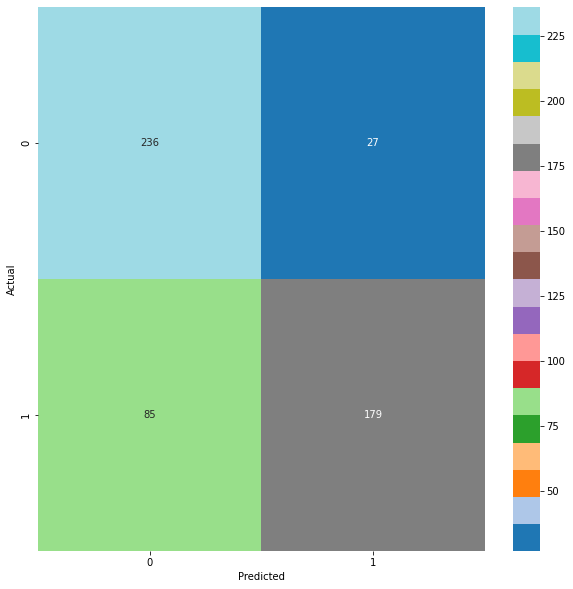

In [21]:
# plot confusion matrix
conf_mat = confusion_matrix(Y_test, preds_test)
fig, ax = plt.subplots(figsize=(10,10))
cmap = "tab20"
sns.heatmap(conf_mat, annot=True, fmt='d',cmap=cmap)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [22]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, preds_test))
test_recall  = "%.4f" % (recall_score(Y_test, preds_test))
test_F1_score  = "%.4f" % (f1_score(Y_test, preds_test))
test_precision  = "%.4f" % (precision_score(Y_test, preds_test))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.7875
recall :  0.6780
F1_score :  0.7617
precision :  0.8689


# 5. Save results to Excel file

In [23]:
# define tarjet
newFile = "../results_set3.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #12', 2:train_accuracy, 3:train_recall, 4:train_F1_score, 5:train_precision, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach
index = 14

# delete row of approach
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)